# Week 3 Lab — Data Wrangling with Pandas
## SeoulCart: Turning Messy Orders into Business Insight

**Kyungdong University (KDU), Global Campus — Department of Smart Computing**

This notebook follows the Week 3 Pandas lab/tutorial in the provided PDF. It creates the synthetic SeoulCart data, inspects and cleans it, merges it with the CRM data, performs business analysis, reshapes the data, and saves the cleaned dataset.

**Learning goals:** inspection, duplicate removal, data-type conversion, missing-value handling, merging, groupby, Boolean filtering, sorting, pivot tables, and melt.

## Business Questions

1. Which product categories and cities bring in the most revenue?
2. How is monthly revenue trending?
3. Who are our best customers, and which registered customers have never bought anything?
4. Can we actually trust this data?

**Deliverables:** this notebook and `orders_clean.csv`.

## Part 0 — Setup and Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.options.display.float_format = "{:,.0f}".format

In [2]:
rng = np.random.default_rng(42)

cities = ["Seoul", "Busan", "Incheon", "Daegu", "Daejeon", "Gwangju"]

customers = pd.DataFrame({
    "customer_id": range(1001, 1061),
    "customer_name": [f"Customer_{i}" for i in range(1, 61)],
    "city": rng.choice(cities, 60, p=[0.35, 0.2, 0.15, 0.1, 0.1, 0.1]),
    "segment": rng.choice(["Regular", "Premium"], 60, p=[0.75, 0.25]),
})

catalog = {
    "Electronics": [("Wireless Earbuds", 59000), ("Phone Charger", 25000),
                    ("Smart Watch", 189000)],
    "Home & Kitchen": [("Air Fryer", 99000), ("Rice Cooker", 129000),
                       ("Water Bottle", 18000)],
    "Fashion": [("Running Shoes", 89000), ("Winter Jacket", 159000),
                ("Backpack", 49000)],
    "Beauty": [("Sunscreen", 22000), ("Face Serum", 45000),
               ("Hand Cream", 12000)],
}

n = 300
rows = []

for i in range(n):
    cat = rng.choice(list(catalog))
    prod, price = catalog[cat][rng.integers(0, 3)]
    day = pd.Timestamp("2026-03-01") + pd.Timedelta(
        days=int(rng.integers(0, 180))
    )
    rows.append({
        "order_id": 5001 + i,
        "customer_id": int(rng.choice(customers["customer_id"].iloc[:50])),
        "order_date": day.strftime("%Y-%m-%d"),
        "category": cat,
        "product": prod,
        "unit_price": f"₩{price:,}",
        "quantity": float(rng.integers(1, 5)),
        "payment_method": rng.choice(["Card", "KakaoPay", "Bank Transfer"]),
    })

orders = pd.DataFrame(rows)

# Make the data realistically messy
orders.loc[rng.choice(n, 15, replace=False), "quantity"] = np.nan
orders.loc[rng.choice(n, 20, replace=False), "payment_method"] = np.nan
orders.loc[rng.choice(n, 40, replace=False), "category"] = orders["category"].str.lower()
orders.loc[rng.choice(n, 25, replace=False), "category"] = " " + orders["category"] + " "
orders.loc[[10, 11, 12], "customer_id"] = 9999

orders = pd.concat([orders, orders.sample(12, random_state=1)], ignore_index=True)
orders = orders.sample(frac=1, random_state=7).reset_index(drop=True)

orders.to_csv("orders_raw.csv", index=False, encoding="utf-8-sig")
customers.to_csv("customers.csv", index=False, encoding="utf-8-sig")

print("Created orders_raw.csv and customers.csv")

Created orders_raw.csv and customers.csv


## Part 1 — Look Before You Touch

In [3]:
orders = pd.read_csv("orders_raw.csv")
customers = pd.read_csv("customers.csv")

print("orders :", orders.shape)
print("customers:", customers.shape)
orders.head(8)

orders : (312, 8)
customers: (60, 4)


,order_id,customer_id,order_date,category,product,unit_price,quantity,payment_method
0,5285,1046,2026-03-29,Home & Kitchen,Air Fryer,"₩99,000",1,Card
1,5171,1042,2026-05-20,Home & Kitchen,Water Bottle,"₩18,000",1,Card
2,5151,1043,2026-08-15,Beauty,Face Serum,"₩45,000",2,KakaoPay
3,5105,1042,2026-07-26,Beauty,Hand Cream,"₩12,000",2,Card
4,5038,1049,2026-03-02,Fashion,Winter Jacket,"₩159,000",1,KakaoPay
5,5102,1031,2026-07-26,Electronics,Wireless Earbuds,"₩59,000",4,Bank Transfer
6,5267,1028,2026-04-10,Beauty,Sunscreen,"₩22,000",2,Card
7,5243,1035,2026-03-29,fashion,Winter Jacket,"₩159,000",2,Card


In [4]:
orders.info()

print("\n--- Missing values per column ---")
print(orders.isna().sum())

print("\nFully duplicated rows:", orders.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 312 entries, 0 to 311
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        312 non-null    int64  
 1   customer_id     312 non-null    int64  
 2   order_date      312 non-null    object 
 3   category        312 non-null    object 
 4   product         312 non-null    object 
 5   unit_price      312 non-null    object 
 6   quantity        297 non-null    float64
 7   payment_method  291 non-null    object 
dtypes: float64(1), int64(2), object(5)
memory usage: 19.6+ KB

--- Missing values per column ---
order_id           0
customer_id        0
order_date         0
category           0
product            0
unit_price         0
quantity          15
payment_method    21
dtype: int64

Fully duplicated rows: 12


In [5]:
print(orders["category"].value_counts())
print("\nSample prices:", orders["unit_price"].head(3).tolist())

category
Beauty              68
Fashion             68
Home & Kitchen      56
Electronics         53
home & kitchen      12
fashion             11
beauty               9
electronics          9
 Home & Kitchen      8
 Fashion             7
 Electronics         5
 Beauty              4
 electronics         1
 home & kitchen      1
Name: count, dtype: int64

Sample prices: ['₩99,000', '₩18,000', '₩45,000']


### Checkpoint — Data problems I found

1. Duplicate rows are present.
2. `unit_price` contains currency symbols and commas, so it is stored as text.
3. `order_date` is stored as text rather than a datetime.
4. `category` contains inconsistent capitalization and whitespace.
5. `quantity` has missing values.
6. `payment_method` has missing values.
7. Some orders use customer ID `9999`, which is absent from the CRM.


## Part 2 — Clean the Data

In [6]:
# Step 2.1 — Remove duplicate rows
rows_before = len(orders)
orders = orders.drop_duplicates()

print(
    f"Rows before: {rows_before} | "
    f"after: {len(orders)} | "
    f"removed: {rows_before - len(orders)}"
)

Rows before: 312 | after: 300 | removed: 12


In [7]:
# Step 2.2 — Fix data types

orders["unit_price"] = (
    orders["unit_price"]
    .str.replace("₩", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

orders["order_date"] = pd.to_datetime(orders["order_date"])

orders.dtypes

order_id                   int64
customer_id                int64
order_date        datetime64[ns]
category                  object
product                   object
unit_price               float64
quantity                 float64
payment_method            object
dtype: object

In [8]:
# Step 2.3 — Standardise text labels
orders["category"] = orders["category"].str.strip().str.title()

orders["category"].value_counts()

category
Fashion           82
Beauty            79
Home & Kitchen    73
Electronics       66
Name: count, dtype: int64

In [9]:
# Step 2.4 — Handle missing values

orders["quantity"] = (
    orders["quantity"]
    .fillna(orders["quantity"].median())
    .astype(int)
)

orders["payment_method"] = orders["payment_method"].fillna("Unknown")

print("Missing values left:", orders.isna().sum().sum())

Missing values left: 0


In [10]:
# Step 2.5 — Create business columns
orders["revenue"] = orders["unit_price"] * orders["quantity"]
orders["month"] = orders["order_date"].dt.strftime("%Y-%m")

orders.head()

,order_id,customer_id,order_date,category,product,unit_price,quantity,payment_method,revenue,month
0,5285,1046,2026-03-29,Home & Kitchen,Air Fryer,"99,000",1,Card,"99,000",2026-03
1,5171,1042,2026-05-20,Home & Kitchen,Water Bottle,"18,000",1,Card,"18,000",2026-05
2,5151,1043,2026-08-15,Beauty,Face Serum,"45,000",2,KakaoPay,"90,000",2026-08
3,5105,1042,2026-07-26,Beauty,Hand Cream,"12,000",2,Card,"24,000",2026-07
4,5038,1049,2026-03-02,Fashion,Winter Jacket,"159,000",1,KakaoPay,"159,000",2026-03


### Cell 11 — Validation

In [11]:
assert orders.duplicated().sum() == 0
assert orders.isna().sum().sum() == 0
assert orders["unit_price"].dtype == "float64"
assert pd.api.types.is_datetime64_any_dtype(orders["order_date"])
assert orders["category"].nunique() == 4

print("Validation successful: the cleaned orders data is analysis-ready.")

Validation successful: the cleaned orders data is analysis-ready.


## Part 3 — Combine Orders with Customers

In [12]:
print("Orders before merge:", len(orders))

inner = pd.merge(orders, customers, on="customer_id", how="inner")
print("Rows after INNER join:", len(inner))

merged = pd.merge(
    orders, customers,
    on="customer_id",
    how="left",
    indicator=True
)

print("Rows after LEFT join :", len(merged))
merged["_merge"].value_counts()

Orders before merge: 300
Rows after INNER join: 297
Rows after LEFT join : 300


_merge
both          297
left_only       3
right_only      0
Name: count, dtype: int64

In [13]:
orphans = merged[merged["_merge"] == "left_only"]

orphans[["order_id", "customer_id", "revenue"]]

,order_id,customer_id,revenue
106,5012,9999,"387,000"
245,5013,9999,"177,000"
267,5011,9999,"54,000"


In [14]:
# Finish the merge and label unmatched customer information honestly
for col in ["city", "segment", "customer_name"]:
    merged[col] = merged[col].fillna("Unknown")

df = merged.drop(columns="_merge")

print(df.shape)
df.head()

(300, 13)


,order_id,customer_id,order_date,category,product,unit_price,quantity,payment_method,revenue,month,customer_name,city,segment
0,5285,1046,2026-03-29,Home & Kitchen,Air Fryer,"99,000",1,Card,"99,000",2026-03,Customer_46,Daejeon,Regular
1,5171,1042,2026-05-20,Home & Kitchen,Water Bottle,"18,000",1,Card,"18,000",2026-05,Customer_42,Daejeon,Regular
2,5151,1043,2026-08-15,Beauty,Face Serum,"45,000",2,KakaoPay,"90,000",2026-08,Customer_43,Daegu,Regular
3,5105,1042,2026-07-26,Beauty,Hand Cream,"12,000",2,Card,"24,000",2026-07,Customer_42,Daejeon,Regular
4,5038,1049,2026-03-02,Fashion,Winter Jacket,"159,000",1,KakaoPay,"159,000",2026-03,Customer_49,Incheon,Regular


### Customers who never bought

In [15]:
never_bought = customers[~customers["customer_id"].isin(orders["customer_id"])]

print("Number of registered customers who never bought:", len(never_bought))
never_bought[["customer_id", "customer_name", "city", "segment"]]

Number of registered customers who never bought: 10


,customer_id,customer_name,city,segment
50,1051,Customer_51,Seoul,Regular
51,1052,Customer_52,Seoul,Regular
52,1053,Customer_53,Daegu,Regular
53,1054,Customer_54,Incheon,Regular
54,1055,Customer_55,Daegu,Regular
55,1056,Customer_56,Daegu,Premium
56,1057,Customer_57,Busan,Premium
57,1058,Customer_58,Incheon,Regular
58,1059,Customer_59,Seoul,Regular
59,1060,Customer_60,Seoul,Regular


## Part 4 — Summarise with Group-By

In [16]:
print(f"Total revenue: ₩{df['revenue'].sum():,.0f}\n")

by_category = (
    df.groupby("category")["revenue"]
      .agg(["sum", "mean", "count"])
      .sort_values("sum", ascending=False)
)

by_category

Total revenue: ₩53,904,000



,sum,mean,count
category,,,
Fashion,"19,665,000","239,817",82
Home & Kitchen,"15,750,000","215,753",73
Electronics,"13,918,000","210,879",66
Beauty,"4,571,000","57,861",79


In [17]:
by_city = (
    df.groupby("city")["revenue"]
      .sum()
      .sort_values(ascending=False)
)

by_city

city
Seoul     16,193,000
Busan     11,175,000
Daegu      9,372,000
Incheon    7,658,000
Daejeon    6,671,000
Gwangju    2,217,000
Unknown      618,000
Name: revenue, dtype: float64

In [18]:
top5 = (
    df.groupby(["customer_id", "customer_name"])["revenue"]
      .sum()
      .reset_index()
      .sort_values("revenue", ascending=False)
      .head(5)
)

top5

,customer_id,customer_name,revenue
15,1016,Customer_16,"2,922,000"
0,1001,Customer_1,"2,451,000"
6,1007,Customer_7,"2,168,000"
4,1005,Customer_5,"2,079,000"
19,1020,Customer_20,"1,816,000"


In [19]:
big_premium = (
    df[(df["revenue"] >= 300000) & (df["segment"] == "Premium")]
      .sort_values("revenue", ascending=False)
      .reset_index(drop=True)
)

print("High-value Premium orders:", len(big_premium))
big_premium[["order_id", "customer_name", "category", "revenue"]].head()

High-value Premium orders: 7


,order_id,customer_name,category,revenue
0,5138,Customer_20,Electronics,"756,000"
1,5018,Customer_13,Fashion,"636,000"
2,5160,Customer_50,Fashion,"636,000"
3,5256,Customer_20,Home & Kitchen,"516,000"
4,5039,Customer_41,Electronics,"378,000"


### Your Turn — Payment Method Revenue

In [20]:
payment_summary = (
    df.groupby("payment_method")["revenue"]
      .agg(total_revenue="sum", number_of_orders="count")
      .sort_values("total_revenue", ascending=False)
)

payment_summary

,total_revenue,number_of_orders
payment_method,,
KakaoPay,"17,594,000",102
Bank Transfer,"16,751,000",88
Card,"14,194,000",90
Unknown,"5,365,000",20


### Your Turn — Average Order Value by Segment

In [21]:
segment_aov = (
    df.groupby("segment")["revenue"]
      .agg(average_order_value="mean", number_of_orders="count")
      .sort_values("average_order_value", ascending=False)
)

segment_aov

if {"Premium", "Regular"}.issubset(segment_aov.index):
    premium_aov = segment_aov.loc["Premium", "average_order_value"]
    regular_aov = segment_aov.loc["Regular", "average_order_value"]
    print(
        f"Premium average order value: ₩{premium_aov:,.0f}"
    )
    print(
        f"Regular average order value: ₩{regular_aov:,.0f}"
    )
    print(
        "Premium spends more per order."
        if premium_aov > regular_aov
        else "Regular spends more per order."
        if regular_aov > premium_aov
        else "Both segments have the same average order value."
    )

Premium average order value: ₩158,857
Regular average order value: ₩183,476
Regular spends more per order.


## Part 5 — Pivot and Reshape

In [22]:
pivot = df.pivot_table(
    index="month",
    columns="category",
    values="revenue",
    aggfunc="sum",
    fill_value=0,
)

pivot["Total"] = pivot.sum(axis=1)
pivot

category,Beauty,Electronics,Fashion,Home & Kitchen,Total
month,,,,,
2026-03,"956,000","1,576,000","3,318,000","2,352,000","8,202,000"
2026-04,"752,000","1,832,000","3,215,000","2,772,000","8,571,000"
2026-05,"725,000","2,807,000","4,273,000","1,371,000","9,176,000"
2026-06,"511,000","1,711,000","2,247,000","2,907,000","7,376,000"
2026-07,"733,000","4,323,000","3,855,000","2,838,000","11,749,000"
2026-08,"894,000","1,669,000","2,757,000","3,510,000","8,830,000"


In [23]:
long = (
    pivot.drop(columns="Total")
         .reset_index()
         .melt(
             id_vars="month",
             var_name="category",
             value_name="revenue"
         )
)

print(long.shape)
long.head(8)

(24, 3)


,month,category,revenue
0,2026-03,Beauty,"956,000"
1,2026-04,Beauty,"752,000"
2,2026-05,Beauty,"725,000"
3,2026-06,Beauty,"511,000"
4,2026-07,Beauty,"733,000"
5,2026-08,Beauty,"894,000"
6,2026-03,Electronics,"1,576,000"
7,2026-04,Electronics,"1,832,000"


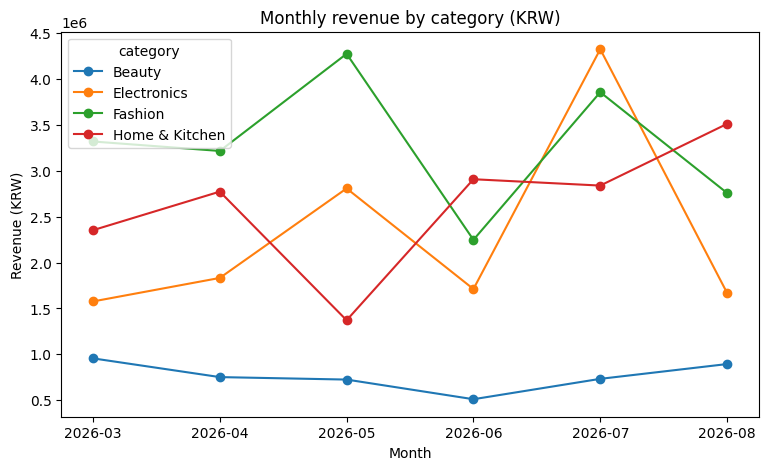

In [24]:
pivot.drop(columns="Total").plot(
    kind="line",
    marker="o",
    figsize=(9, 5),
    title="Monthly revenue by category (KRW)"
)

plt.ylabel("Revenue (KRW)")
plt.xlabel("Month")
plt.show()

### Your Turn — Cities × Segments

In [25]:
city_segment = df.pivot_table(
    index="city",
    columns="segment",
    values="revenue",
    aggfunc="sum",
    fill_value=0,
)

city_segment["Total"] = city_segment.sum(axis=1)
city_segment

segment,Premium,Regular,Unknown,Total
city,,,,
Busan,"573,000","10,602,000",0,"11,175,000"
Daegu,0,"9,372,000",0,"9,372,000"
Daejeon,"669,000","6,002,000",0,"6,671,000"
Gwangju,"54,000","2,163,000",0,"2,217,000"
Incheon,"5,218,000","2,440,000",0,"7,658,000"
Seoul,"1,270,000","14,923,000",0,"16,193,000"
Unknown,0,0,"618,000","618,000"


In [26]:
premium_share = (
    city_segment["Premium"] /
    city_segment["Total"] * 100
).sort_values(ascending=False)

print("Premium revenue share by city (%):")
print(premium_share)

if len(premium_share) > 0:
    print(
        f"Highest Premium revenue share: {premium_share.index[0]} "
        f"({premium_share.iloc[0]:.1f}%)"
    )

Premium revenue share by city (%):
city
Incheon   68
Daejeon   10
Seoul      8
Busan      5
Gwangju    2
Daegu      0
Unknown    0
dtype: float64
Highest Premium revenue share: Incheon (68.1%)


## Part 6 — Save and Report

In [27]:
df.to_csv("orders_clean.csv", index=False)

print(
    "Saved orders_clean.csv with",
    df.shape[0],
    "rows and",
    df.shape[1],
    "columns"
)

Saved orders_clean.csv with 300 rows and 13 columns


## Findings

1. **Revenue drivers:** Use `by_category` and `by_city` above to identify the highest-revenue category and city.
2. **Monthly trend:** Use the monthly pivot table and chart to describe the March–August trend and identify the peak/low month.
3. **Customers:** Use `top5` for the highest-value customers and `never_bought` for registered customers with no orders.
4. **Data quality:** Duplicate rows, inconsistent categories, text-formatted prices/dates, missing values, and CRM-orphan orders were identified and handled.

## Recommendations

1. Monitor the highest-revenue categories and cities during planning.
2. Investigate the monthly peak and the category contributing most to it.
3. Improve the order/CRM integration so unmatched customer IDs are flagged before reporting.

## Cleaning steps applied (and why)

- Removed exact duplicate rows to prevent revenue inflation.
- Converted `unit_price` from currency-formatted text to numeric.
- Converted `order_date` to datetime.
- Standardised category labels using trimming and title case.
- Filled missing quantities with the median.
- Filled missing payment methods with `"Unknown"` rather than guessing.
- Added `revenue` and `month` for analysis.
- Used a left join to preserve all orders and explicitly identify unmatched CRM records.


## Submission Checklist

- [x] Notebook runs top-to-bottom.
- [x] Validation task completed.
- [x] Customers who never bought identified.
- [x] Payment method revenue analysed.
- [x] Segment average order value analysed.
- [x] City × segment pivot created.
- [x] Findings and recommendations included.
- [x] `orders_clean.csv` saved.
